In [4]:
# LOAD DATA
import pandas as pd

data = pd.read_csv('C:/ml-churn-project/data/Telco_customer_churn.csv')

# Matikan pemotongan kolom
pd.set_option('display.max_columns', None) 

# tampilkan 5 data teratas 
data.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
# EXPLORARY DATA ANALYSIS (EDA) 
# info data 
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

In [8]:
cols = ['Internet Service','Online Security','Tech Support','Streaming TV','Streaming Movies','Multiple Lines','Online Backup','Device Protection','Phone Service']
for i in data[cols].columns:
    print(f"Unique values in '{i}': {data[i].unique()}\n")

Unique values in 'Internet Service': <ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

Unique values in 'Online Security': <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

Unique values in 'Tech Support': <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Unique values in 'Streaming TV': <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Unique values in 'Streaming Movies': <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Unique values in 'Multiple Lines': <ArrowStringArray>
['No', 'Yes', 'No phone service']
Length: 3, dtype: str

Unique values in 'Online Backup': <ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

Unique values in 'Device Protection': <ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

Unique values in 'Phone Service': <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str



In [47]:
cols = ['Internet Service','Payment Method','Phone Service','Multiple Lines','Online Security']
for col in cols:
    print(f"Value counts grouped by Churn Value for {col}:")
    print(data.groupby(col)['Churn Value'].value_counts(normalize=True))
    print("\n")

Value counts grouped by Churn Value for Internet Service:
Internet Service  Churn Value
DSL               0              0.810409
                  1              0.189591
Fiber optic       0              0.581072
                  1              0.418928
No                0              0.925950
                  1              0.074050
Name: proportion, dtype: float64


Value counts grouped by Churn Value for Payment Method:
Payment Method             Churn Value
Bank transfer (automatic)  0              0.832902
                           1              0.167098
Credit card (automatic)    0              0.847569
                           1              0.152431
Electronic check           0              0.547146
                           1              0.452854
Mailed check               0              0.808933
                           1              0.191067
Name: proportion, dtype: float64


Value counts grouped by Churn Value for Phone Service:
Phone Service  Churn Value
No   

In [48]:
cols = ['Online Backup','Device Protection','Tech Support','Streaming TV','Streaming Movies']
for col in cols:
    print(f"Value counts grouped by Churn Value for {col}:")
    print(data.groupby(col)['Churn Value'].value_counts(normalize=True))
    print("\n")

Value counts grouped by Churn Value for Online Backup:
Online Backup  Churn Value
0              0              0.708279
               1              0.291721
1              0              0.784685
               1              0.215315
Name: proportion, dtype: float64


Value counts grouped by Churn Value for Device Protection:
Device Protection  Churn Value
0                  0              0.713482
                   1              0.286518
1                  0              0.774979
                   1              0.225021
Name: proportion, dtype: float64


Value counts grouped by Churn Value for Tech Support:
Tech Support  Churn Value
0             0              0.688138
              1              0.311862
1             0              0.848337
              1              0.151663
Name: proportion, dtype: float64


Value counts grouped by Churn Value for Streaming TV:
Streaming TV  Churn Value
0             0              0.756688
              1              0.243312
1      

In [30]:
# describe data 
data.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [31]:
# cek missing value
print(f"Jumlah missing value per kolom:\n{data.isnull().sum()}")

Jumlah missing value per kolom:
CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64


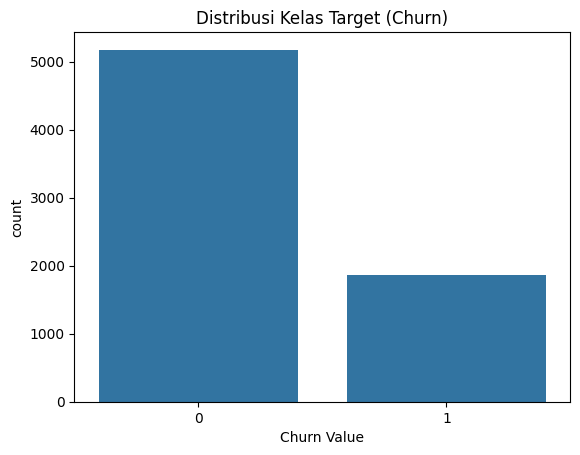

Churn Value
0    5174
1    1869
Name: count, dtype: int64


In [32]:
# distribusi kelas target 
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Churn Value', data=data)
plt.title('Distribusi Kelas Target (Churn)')    
plt.show()
print(data['Churn Value'].value_counts())

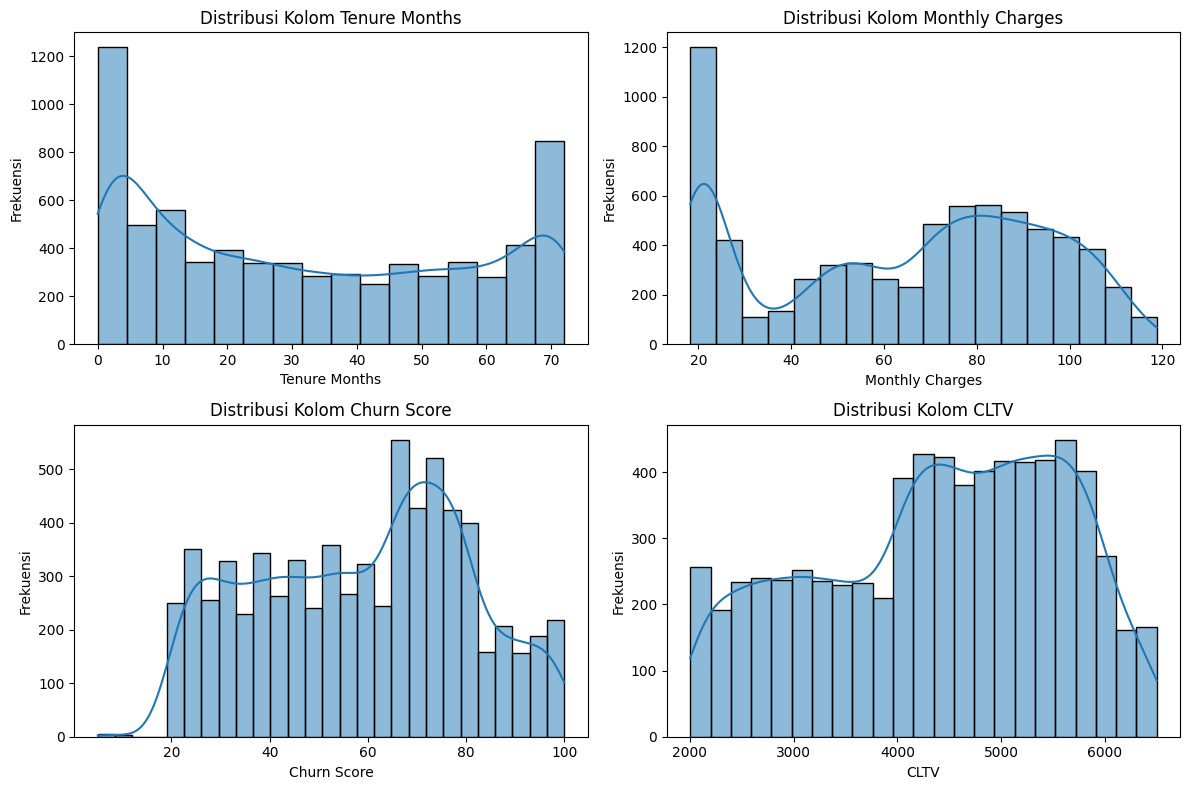

In [33]:
# distribusi kelas kolom numerik 
plt.figure(figsize=(12, 8))
for i,col in enumerate(data.drop(columns=['Churn Value','CustomerID',
                                          'Count','Country',
                                          'State','City',
                                          'Zip Code','Lat Long',
                                          'Latitude','Longitude'
                                          ]).select_dtypes(include='number').columns):
    plt.subplot(2, 2, i+1)
    sns.histplot(x=col, data=data, kde=True)
    plt.title(f'Distribusi Kolom {col}')
    plt.xlabel(col)
    plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()


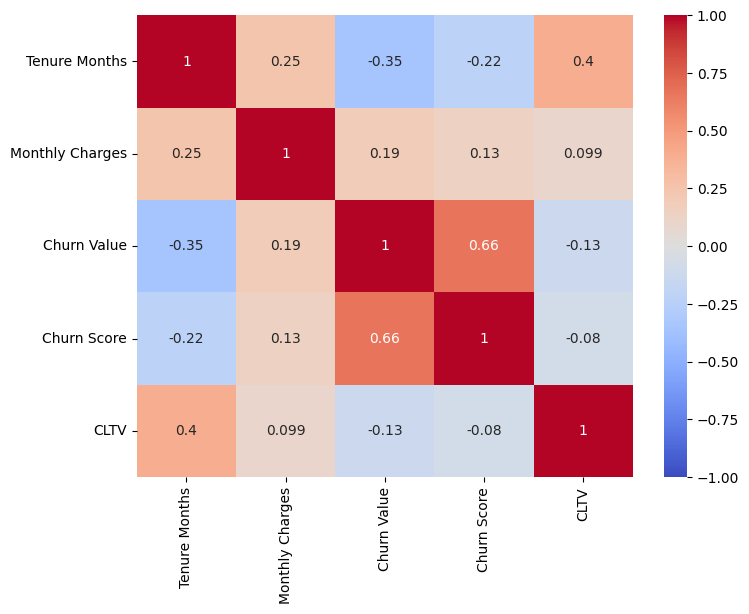

In [34]:
# heatmap untuk melihat korelasi antar kolom numerik 
plt.figure(figsize=(8, 6))
datacorr = data.drop(columns=['CustomerID',
                              'Count','Country',
                              'State','City',
                              'Zip Code','Lat Long',
                              'Latitude','Longitude'
                              ]).select_dtypes(include='number').corr()
sns.heatmap(datacorr,vmax=1, vmin=-1, center=0,annot=True, cmap='coolwarm')
plt.show()

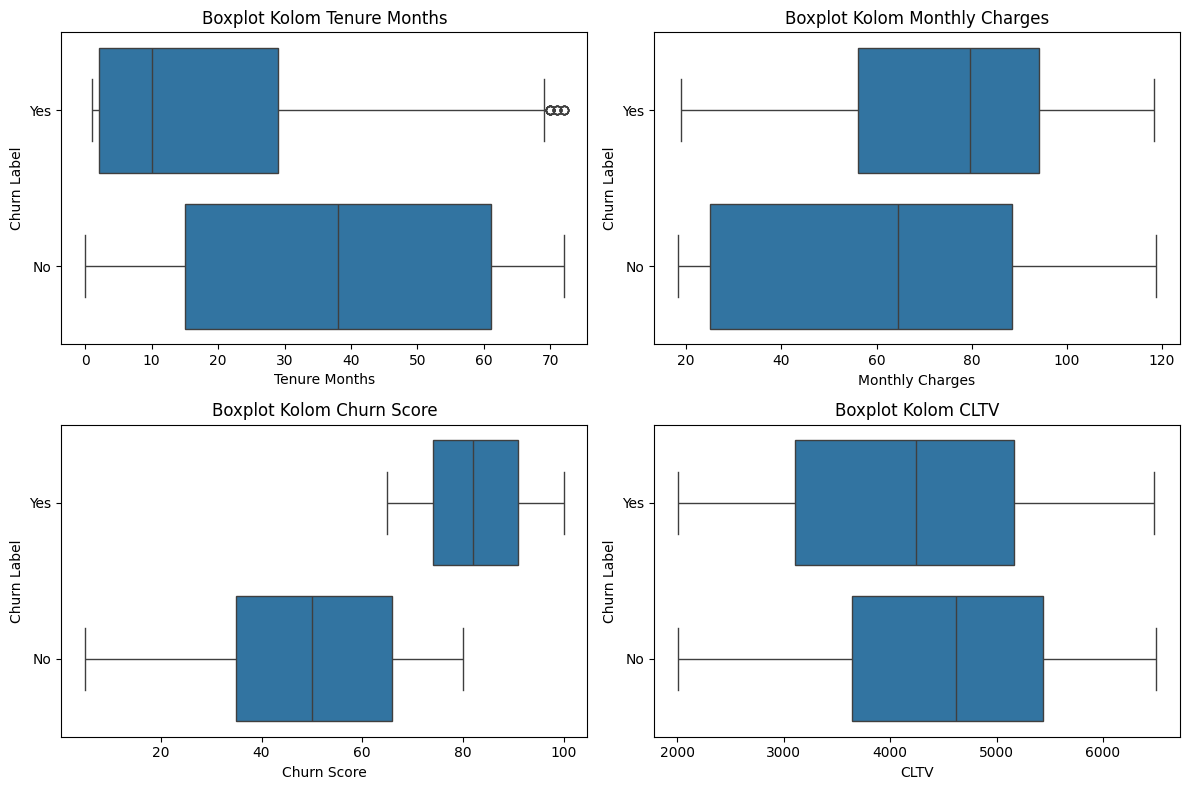

In [35]:
# boxplot untuk melihat outlier pada kolom numerik 
plt.figure(figsize=(12, 8))
for i,col in enumerate(data.drop(columns=['Churn Value','CustomerID',
                                          'Count','Country',
                                          'State','City',
                                          'Zip Code','Lat Long',
                                          'Latitude','Longitude'
                                          ]).select_dtypes(include='number').columns):
    plt.subplot(2, 2, i+1)
    sns.boxplot(x=col,y='Churn Label', data=data)
    plt.title(f'Boxplot Kolom {col}')
plt.tight_layout()
plt.show()  


<!-- 
Dari boxplot di atas kita bisa melihat bahwa tidak ada outlier di data nummerik, jadi proses capping atau cliping data tidak di perlukan 
-->

             RANGKUMAN (EDA) Exploratory Data Analysis

-----------------------------------------------------------------------------
1. Deskripsi dan Kualitas Data
Jumlah Data: Dataset terdiri dari 7.043 baris dan 33 kolom.

    Missing Values: Hanya kolom Churn Reason yang memiliki nilai kosong sebanyak 5.174. Kolom lain bersih dari missing values.

    Statistik Deskriptif:

    Tenure Months: Rata-rata pelanggan telah berlangganan selama 32 bulan, dengan durasi maksimal 72 bulan.

    Monthly Charges: Biaya bulanan rata-rata adalah 64,76, dengan nilai tertinggi mencapai 118,75.

    Total Charges: Kolom ini terdeteksi sebagai tipe data String (Object), sehingga perlu dikonversi ke numerik untuk proses pemodelan.
-----------------------------------------------------------------------------
2. Distribusi Class Target
Target variabel dalam data ini adalah Churn Value (atau Churn Label).

    Nilai rata-rata pada Churn Value adalah 0,265. Ini menunjukkan bahwa sekitar 26,5% pelanggan telah berhenti (churn), sementara sisanya (73,5%) tetap berlangganan. Terdapat ketidakseimbangan kelas (imbalance) yang perlu diperhatikan saat melatih model.
-----------------------------------------------------------------------------
3. Fitur yang Perlu Dihapus (Drop Columns)
Beberapa kolom harus dihapus agar model tidak mengalami overfitting atau data leakage:

    CustomerID & Count: Merupakan ID unik dan nilai statis (selalu 1) yang tidak memberikan informasi prediktif.

    Geospasial (Country, State, City, Zip Code, Lat Long, Latitude, Longitude): Data lokasi ini dianggap tidak berguna untuk performa model dasar.

    Churn Score & Churn Reason: Berpotensi menyebabkan data leakage karena informasi ini biasanya didapatkan setelah pelanggan dipastikan churn.

    Churn Value / Churn Label: Salah satu harus dihapus jika yang lainnya digunakan sebagai target, untuk menghindari duplikasi target dalam fitur.
-----------------------------------------------------------------------------
4. Analisis Outlier
    Berdasarkan ringkasan statistik (describe), fitur numerik utama seperti Monthly Charges dan Tenure Months memiliki distribusi yang wajar tanpa lonjakan nilai yang ekstrem (maksimal masih dalam batas logis layanan telco).

    Oleh karena itu, dalam tahap ini tidak ditemukan outlier yang memerlukan penanganan khusus seperti capping atau clipping.
-----------------------------------------------------------------------------

<!-- 
Sekarang kita drop kolom-kolom yang tidak di butuhkan seperti
'CustomerID' dan 'Count' karena data unik juga tidak ada nilai statiknya

'Country','State','City','Zip Code','Lat Long','Latitude','Longitude'
data ini adalah data geopasial yang tidak berguna untuk model

'Churn Value','Churn Score','Churn Reason' data ini tidak di perlukan karena data missing value dan data prediksi (berpotensi menyebabkan data leakage) 
 -->

In [36]:
# feature engineering  
# 2. Total Services (jumlah layanan yang digunakan)
cols_to_map = ['Online Security', 'Online Backup', 'Device Protection', 
                'Tech Support', 'Streaming TV', 'Streaming Movies']

mapping = {'Yes': 1, 'No': 0, 'No internet service': 0}
for col in cols_to_map:
    data[col] = data[col].replace(mapping)
    
data['Total Services'] = data[cols_to_map].sum(axis=1)

# 3. Tenure Grouping (kelompokkan masa keanggotaan)
data['Tenure Group'] = pd.cut(data['Tenure Months'], 
                            bins=[-1, 6, 24, 100], 
                            labels=['Newbie', 'Active', 'Loyal'],
                            include_lowest=True)

# 4. Contract Flag (untuk kontrak month-to-month paling rawan churn)
data['Is Month To Month'] = (data['Contract'] == 'Month-to-month').astype(int)

# 5. Total Charges (Handle missing values/non-numeric)
data['Total Charges'] = pd.to_numeric(data['Total Charges'], errors='coerce').fillna(0)

# 6. Avg Monthly Charges (hitung rata-rata biaya bulanan)
data['Avg Monthly Charges'] = data['Total Charges'] / (data['Tenure Months'] + 1)

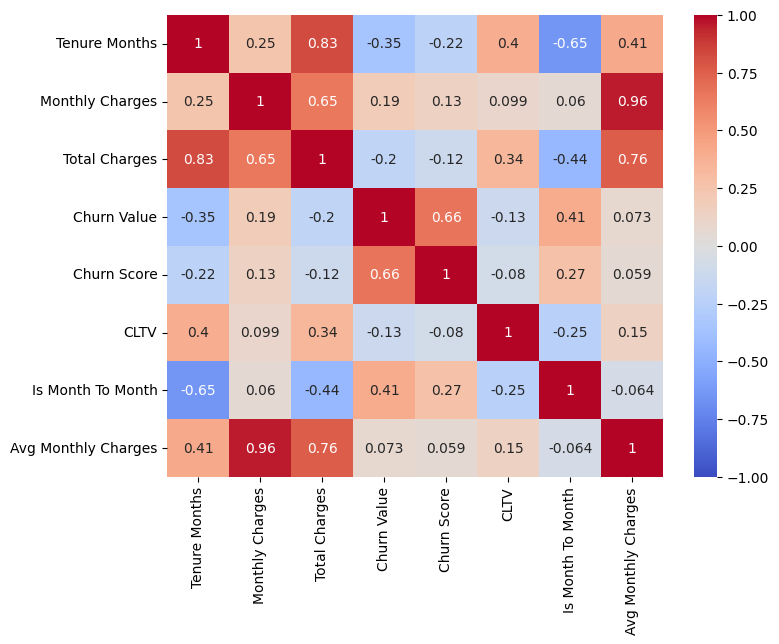

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
# heatmap untuk melihat korelasi antar kolom numerik 
plt.figure(figsize=(8, 6))
datacorr = data.drop(columns=['CustomerID',
                              'Count','Country',
                              'State','City',
                              'Zip Code','Lat Long',
                              'Latitude','Longitude'
                              ]).select_dtypes(include='number').corr()
sns.heatmap(datacorr,vmax=1, vmin=-1, center=0,annot=True, cmap='coolwarm')
plt.show()

In [38]:
cols = []
print(data.groupby('Tenure Group')['Churn Value'].value_counts(normalize=True))

Tenure Group  Churn Value
Newbie        1              0.529372
              0              0.470628
Active        0              0.683632
              1              0.316368
Loyal         0              0.859640
              1              0.140360
Name: proportion, dtype: float64


In [39]:
data = data.drop(columns=['CustomerID', 'Count', 'Country', 'State', 'City', 
                    'Zip Code', 'Lat Long', 'Latitude', 'Longitude','Gender',
                    'Churn Score', 'Churn Reason', 'Churn Label'])

In [40]:
data.columns.to_list()

['Senior Citizen',
 'Partner',
 'Dependents',
 'Tenure Months',
 'Phone Service',
 'Multiple Lines',
 'Internet Service',
 'Online Security',
 'Online Backup',
 'Device Protection',
 'Tech Support',
 'Streaming TV',
 'Streaming Movies',
 'Contract',
 'Paperless Billing',
 'Payment Method',
 'Monthly Charges',
 'Total Charges',
 'Churn Value',
 'CLTV',
 'Total Services',
 'Tenure Group',
 'Is Month To Month',
 'Avg Monthly Charges']

In [41]:
cols_to_map = ['Online Security', 'Online Backup', 'Device Protection', 
                'Tech Support', 'Streaming TV', 'Streaming Movies']

mapping = {'Yes': 1, 'No': 0, 'No internet service': 0}
for col in cols_to_map:
    data[col] = data[col].replace(mapping)

In [42]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_features = [
    'Tenure Months', 'Monthly Charges', 'Total Charges', 
    'Total Services', 'Avg Monthly Charges', 'Is Month To Month'
]

# 2. Fitur Ordinal
ordinal_features = ['Tenure Group', 'Contract']

ordinal_order = [
    ['Newbie', 'Active', 'Loyal'],          # Urutan TenureGroup
    ['Month-to-month', 'One year', 'Two year'] # Urutan Contract
]

# 3. Fitur Nominal
nominal_features = [
    'Senior Citizen', 'Partner', 'Dependents', 
    'Phone Service', 'Multiple Lines', 'Internet Service', 
    'Online Security', 'Online Backup', 'Device Protection', 
    'Tech Support', 'Streaming TV', 'Streaming Movies', 
    'Paperless Billing', 'Payment Method'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('ord', OrdinalEncoder(categories=ordinal_order), ordinal_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), nominal_features)
    ],
    remainder='drop'
)




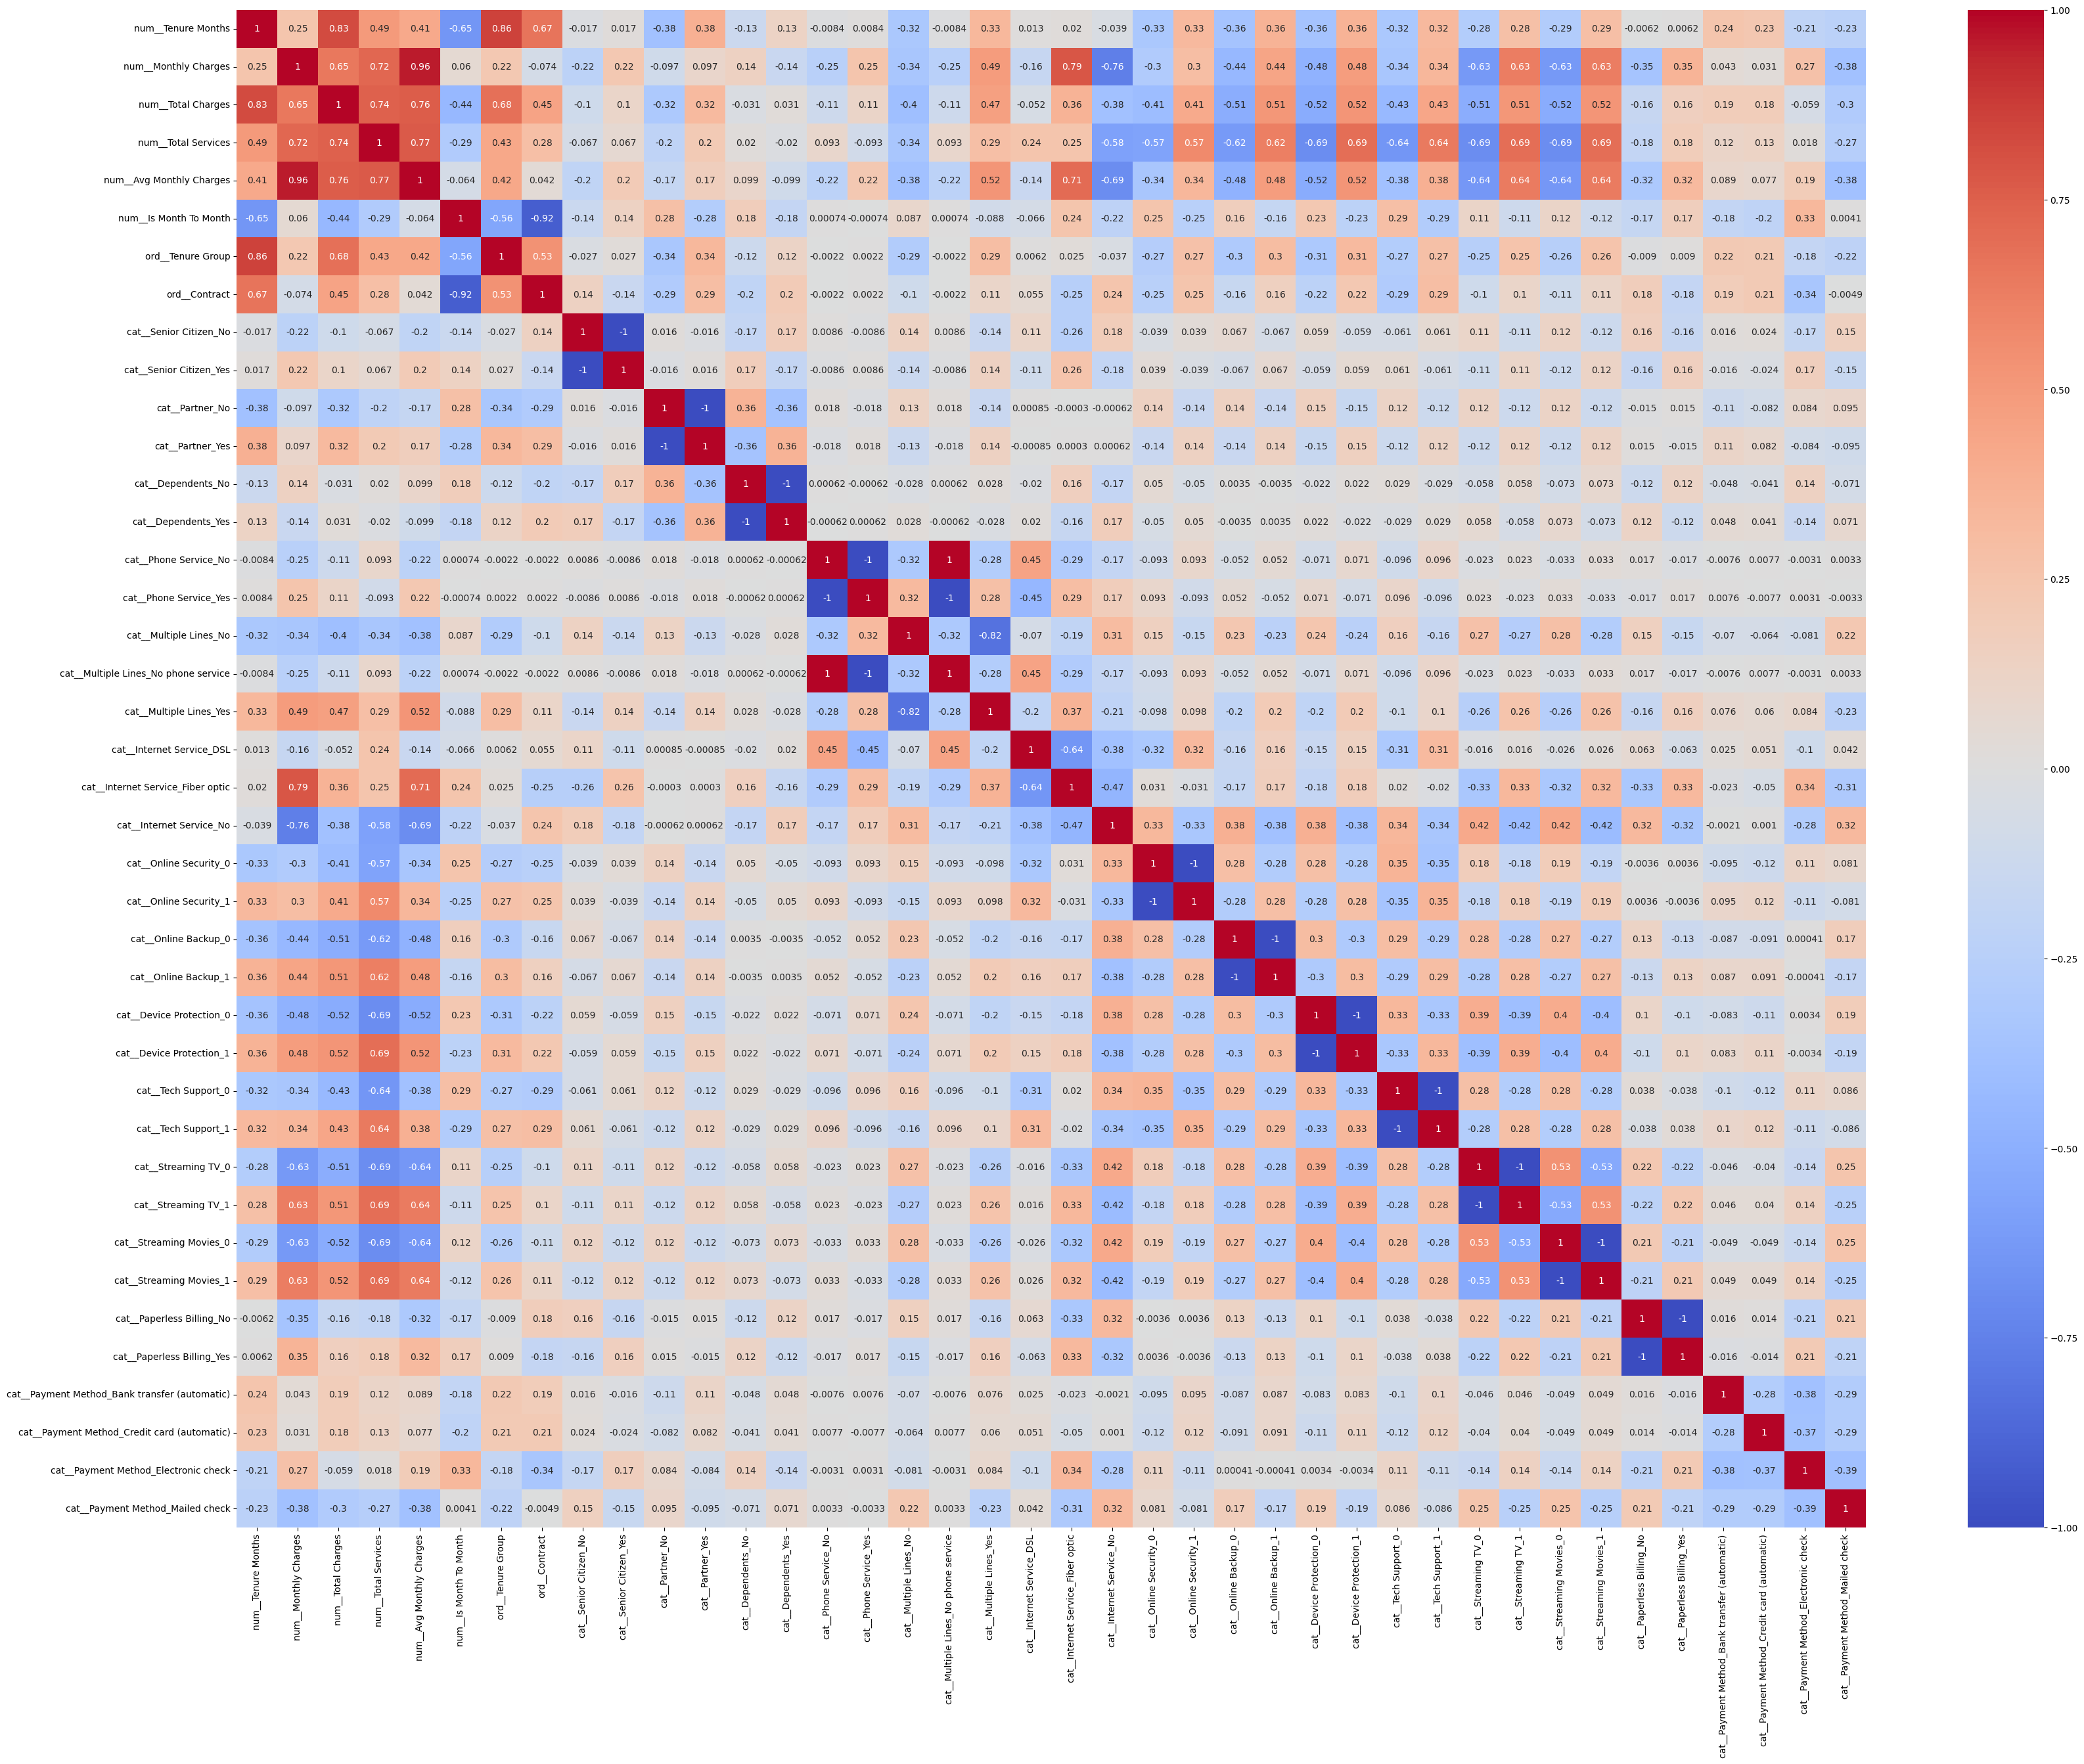

In [43]:
# heatmap untuk melihat korelasi antar kolom numerik 
# 1. Lakukan fit_transform pada data asli Anda (misal df)
# Pastikan df sudah berisi kolom-kolom yang sesuai dengan 'numeric_features', dll.
X_processed = preprocessor.fit_transform(data)

# 2. Ambil nama kolom baru secara otomatis dari preprocessor
# Ini akan menangani penamaan fitur hasil OneHot secara otomatis
feature_names = preprocessor.get_feature_names_out()

# 3. Ubah menjadi DataFrame
df_processed = pd.DataFrame(X_processed, columns=feature_names)

plt.figure(figsize=(40,30))
datacorr = df_processed.corr()
sns.heatmap(datacorr,vmax=1, vmin=-1, center=0,annot=True, cmap='coolwarm')
plt.show()


24